In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../../')

import phys_ml.visualization.vertex_visualization as vertvis
from phys_ml.evaluation import vertex as verteval
from phys_ml.load_data.vertex import *
from phys_ml.trainer.vertex import *

## Sanity check

In [ ]:
import numpy as np
import torch

save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_1'
vertex = AutoEncoderVertex24x6Dataset.load_from_file('../../../frgs_6d/tp0.020000_mu0.080000.h5')
trainer = VertexTrainer24x6(project_name='vertex_24x6', load_from=save_path)
_ = trainer.init_trainer(train_mode=TrainerModes.JUPYTER, load_from=save_path)

In [ ]:
# real sample
l, d = 24, 6
idcs = [18] * d
sample = torch.tensor(AutoEncoderVertex24x6Dataset.get_vector_from_vertex(vertex, *idcs), dtype=torch.float32)

# random value samples
torch.manual_seed(12)
r1 = torch.randn(len(sample))
r2 = torch.randn(len(sample))
r3 = torch.randn(len(sample))

# insert real values at construction axis
axis = 3  # trainer.config.construction_axis
sl = slice(axis * l, (axis +1) * l)
values_at_axis = sample[sl]
r1[sl] = values_at_axis
r2[sl] = values_at_axis
r3[sl] = values_at_axis

# predict
idcs = torch.tensor(idcs, dtype=torch.int64).to('cuda')
p_true = trainer.wrapper.predict_step((sample.reshape(1, -1).to('cuda'), [idcs]))
p1 = trainer.wrapper.predict_step((r1.reshape(1, -1).to('cuda'), [idcs]))
p2 = trainer.wrapper.predict_step((r2.reshape(1, -1).to('cuda'), [idcs]))
p3 = trainer.wrapper.predict_step((r3.reshape(1, -1).to('cuda'), [idcs]))

In [ ]:
# sum of absolute errors
(np.abs(values_at_axis - p_true.detach().cpu()[0]).sum(),
np.abs(values_at_axis - p1.detach().cpu()[0]).sum(),
np.abs(values_at_axis - p2.detach().cpu()[0]).sum(),
np.abs(values_at_axis - p3.detach().cpu()[0]).sum())

(tensor(0.1507), tensor(18.3892), tensor(14.5852), tensor(14.7258))

## vertex statistics

In [ ]:
data_dir = '/gpfs/data/fs71925/shepp123/frgs_6d/'
verteval.vertex_statistics(data_dir)

## comparison to zan24

In [6]:
import numpy as np


def rmse_to_zan24(rmse: float, V: np.ndarray, n: int = 24**6, downsample: int = 144**3) -> float:
    V = np.random.choice(V.flatten(), size=downsample, replace=False)
    error_sum = (rmse * np.sqrt(n))**2
    adjusted_es = error_sum / n * downsample
    return np.sqrt(adjusted_es) / np.linalg.norm(V)


def load_and_rmse_to_zan24(rmse: float, fp: str, n: int = 24**6, downsample: int = 144**3) -> float:
    V = AutoEncoderVertex24x6Dataset.load_from_file(fp)
    return rmse_to_zan24(rmse, V, n, downsample)


data_dir = '/gpfs/data/fs71925/shepp123/frgs_6d/'
rmse_df = pd.read_csv('reconstruction_results.csv')
filepaths = AutoEncoderVertex24x6Dataset.get_filepaths(data_dir, subset=None, subset_shuffle=False)[0]
fp_dict = {float(Path(fp).stem[2:6]): fp for fp in filepaths}
errors = ['0.051008', '0.050846', '0.052797', '0.050148', '0.04994', '0.04968', '0.049482', '0.049657', '0.049895', '0.050421', '0.051805', 
          '0.054238', '0.057537', '0.062715', '0.06484', '0.064643', '0.065063', '0.066254', '0.066368', '0.067269', '0.068122', '0.068525', 
          '0.068792', '0.069272', '0.07033', '0.076447', '0.08041', '0.080816', '0.083482', '0.084816', '0.090107', '0.095451', '0.096641', 
          '0.100824', '0.09115', '0.082856', '0.086178', '0.081111', '0.0803', '0.081256', '0.087704', '0.105343', '0.096102', '0.092997', 
          '0.103273', '0.08859', '0.078509', '0.071454', '0.069971', '0.071316', '0.078705']
df = rmse_df[rmse_df['run_id'] == '1_1'].copy()
df['error_zan24'] = errors
df['error'] = df.apply(lambda row: load_and_rmse_to_zan24(row['rmse'], fp_dict[row['tp']]), axis=1)
df.to_csv('errors_compare_zan24.csv', index=False)
df

,run_id,ld,s,tp,rmse,train_data,contrastive,train_phase,error_zan24,error
459,1_1,32,24000,0.00,0.006174,True,False,True,0.051008,0.001645
460,1_1,32,24000,0.01,0.006166,True,False,True,0.050846,0.001644
461,1_1,32,24000,0.02,0.006230,True,False,True,0.052797,0.001651
462,1_1,32,24000,0.03,0.006180,True,False,True,0.050148,0.001641
463,1_1,32,24000,0.04,0.006199,True,False,True,0.04994,0.001639
464,1_1,32,24000,0.05,0.006203,True,False,True,0.04968,0.001636
465,1_1,32,24000,0.06,0.006252,True,False,True,0.049482,0.001633
466,1_1,32,24000,0.07,0.006283,True,False,True,0.049657,0.001627
467,1_1,32,24000,0.08,0.006371,True,False,True,0.049895,0.001629
468,1_1,32,24000,0.09,0.006436,True,False,True,0.050421,0.001622


In [7]:
import pandas as pd

error_df = pd.read_csv('errors_compare_zan24.csv')
mean_error = error_df[['error_zan24', 'error']].mean()
print(mean_error)
print(f"error in zan24 is {mean_error['error_zan24'] / mean_error['error']:.2f} times higher")
print(f"error is {(mean_error['error'] / mean_error['error_zan24']) * 100:.2f}% of zan24 error")

error_zan24    0.072656
error          0.002081
dtype: float64
error in zan24 is 34.92 times higher
error is 2.86% of zan24 error


## correlation analysis

In [ ]:
vertex_dir = '/gpfs/data/fs71925/shepp123/frgs_6d'
cor_mat = verteval.vertex_correlation(vertex_dir=vertex_dir, pre_load_vertices=True, vertex_file_ending='h5')

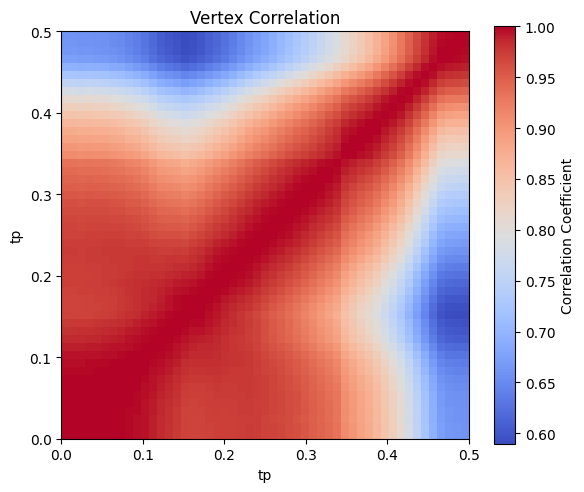

In [8]:
vertvis.plot_correlation(cor_mat, 'Vertex Correlation')

In [ ]:
vertex_dir = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/2_1_1_ld32/latentspaces'
cor_mat = verteval.vertex_correlation(vertex_dir=vertex_dir, pre_load_vertices=True, vertex_file_ending='npy')

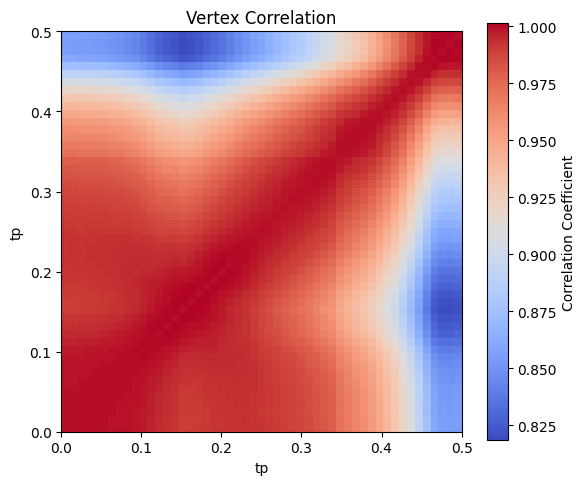

In [4]:
vertvis.plot_correlation(cor_mat, 'Vertex Correlation')

In [ ]:
vertex_dir = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/1_1_ld32/latentspaces'
cor_mat = verteval.vertex_correlation(vertex_dir=vertex_dir, pre_load_vertices=True, vertex_file_ending='npy')

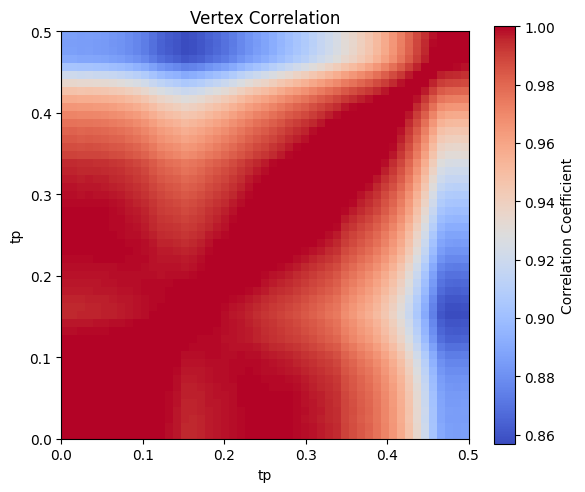

In [7]:
vertvis.plot_correlation(cor_mat, 'Vertex Correlation', vmin=None)

In [ ]:
vertex_dir = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/1_2_ld32/latentspaces'
cor_mat = verteval.vertex_correlation(vertex_dir=vertex_dir, pre_load_vertices=True, vertex_file_ending='npy')

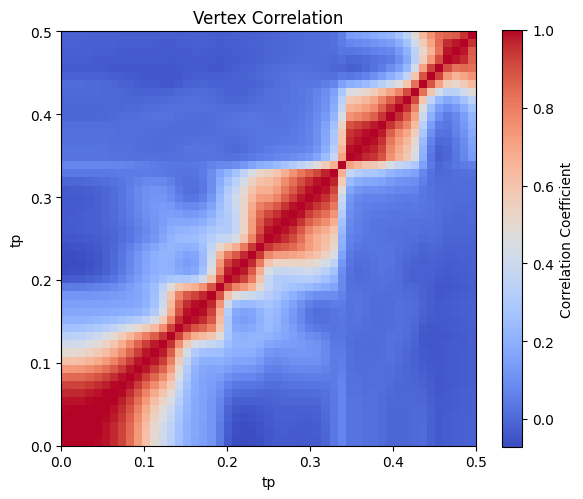

In [9]:
vertvis.plot_correlation(cor_mat, 'Vertex Correlation', vmin=None)